In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import pickle
from tensorflow.keras.utils import image_dataset_from_directory

In [2]:
training_set = image_dataset_from_directory(
    'train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 76515 files belonging to 4 classes.


In [3]:
validation_set = image_dataset_from_directory(
    'val',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 21861 files belonging to 4 classes.


In [4]:
training_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 4), dtype=tf.float32, name=None))>

In [5]:
INPUT_SHAPE = (224, 224, 3)

In [6]:
mobnet = tf.keras.applications.MobileNetV3Large(
    input_shape=INPUT_SHAPE,
    alpha=1.0,
    minimalistic=False,
    include_top=True,
    weights="imagenet",
    input_tensor=None,
    classes=1000,
    pooling=None,
    dropout_rate=0.2,
    classifier_activation="softmax",
    include_preprocessing=True,
    # name="MobileNetV3Large",
)

In [7]:
#mobnet.trainable = False #--used to freeze weights of this pretrained model 

In [8]:
model = tf.keras.models.Sequential()

In [9]:
model.add(tf.keras.Input(shape=INPUT_SHAPE))

In [10]:
model.add(mobnet)

In [11]:
model.add(tf.keras.layers.Dense(units = 4,activation='softmax'))

In [12]:
metrics_list = [
    "accuracy",
    tf.keras.metrics.Precision(name="precision"),
    tf.keras.metrics.Recall(name="recall")
]


In [13]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001)
,loss='categorical_crossentropy',metrics=metrics_list)

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ MobileNetV3Large (Functional)   │ (None, 1000)           │     5,507,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         4,004 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,511,436 (21.02 MB)

 Trainable params: 5,487,036 (20.93 MB)

 Non-trainable params: 24,400 (95.31 KB)

In [ ]:
training_history = model.fit(
    x=training_set,
    validation_data=validation_set,
    epochs=5)

Epoch 1/5
2392/2392 ━━━━━━━━━━━━━━━━━━━━ 5276s 2s/step - accuracy: 0.8817 - loss: 1.1248 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9012 - val_loss: 0.9529 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/5
2189/2392 ━━━━━━━━━━━━━━━━━━━━ 7:28 2s/step - accuracy: 0.8990 - loss: 0.8924 - precision: 0.5653 - recall: 0.1104

In [ ]:
model.save("Trained_Model.h5")

In [ ]:
model.save("Trained_Model.keras")

In [ ]:
# Saving history
with open('Training_history.pkl', 'wb') as f:
    pickle.dump(training_history.history, f)

In [ ]:
#Reloading History from pickle
with open('Training_history.pkl', 'rb') as f:
    load_history = pickle.load(f)
load_history

{'accuracy': [0.88116055727005,
  0.8974710702896118,
  0.9424426555633545,
  0.9596027135848999,
  0.9653401374816895],
 'loss': [1.1321357488632202,
  0.8329931497573853,
  0.6253105401992798,
  0.4836404621601105,
  0.37522584199905396],
 'precision': [0.0,
  0.969679594039917,
  0.9740851521492004,
  0.9765068888664246,
  0.9778419137001038],
 'recall': [0.0,
  0.37617459893226624,
  0.7879631519317627,
  0.790407121181488,
  0.8858916759490967],
 'val_accuracy': [0.8973972201347351,
  0.8917707204818726,
  0.9438726305961609,
  0.9630849361419678,
  0.9576414823532104],
 'val_loss': [0.9670173525810242,
  0.7172191143035889,
  0.5570108890533447,
  0.42590954899787903,
  0.34219175577163696],
 'val_precision': [0.0,
  0.9782508611679077,
  0.9795347452163696,
  0.9749621748924255,
  0.9817178845405579],
 'val_recall': [0.0,
  0.7756735682487488,
  0.7684918642044067,
  0.7962124347686768,
  0.8793742060661316]}

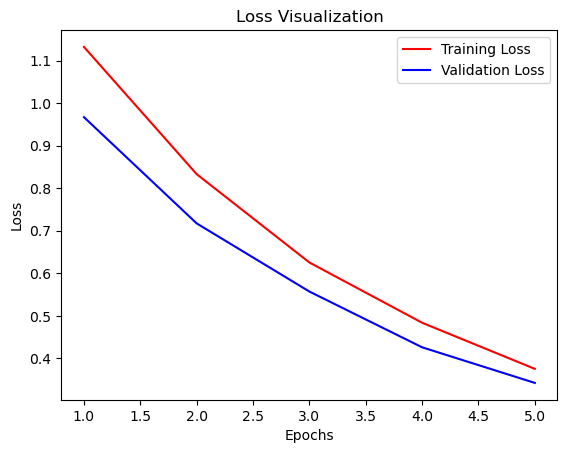

In [ ]:
loss = load_history['loss']
val_loss = load_history['val_loss']
epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, color='red', label='Training Loss')
plt.plot(epochs, val_loss, color='blue', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Visualization')
plt.legend()
plt.show()


In [ ]:
test_set = validation_set = image_dataset_from_directory(
    'test',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=64,
    image_size=(224, 224),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 10933 files belonging to 4 classes.


In [ ]:
results = model.evaluate(test_set)

test_loss      = results[0]
test_acc       = results[1]
test_precision = results[2]
test_recall    = results[3]

# Compute F1 Score
f1_score = 2 * (test_precision * test_recall) / (test_precision + test_recall + 1e-7)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)
print("Precision:", test_precision)
print("Recall:", test_recall)
print("F1 Score:", f1_score)


171/171 ━━━━━━━━━━━━━━━━━━━━ 291s 2s/step - accuracy: 0.9534 - loss: 0.3477 - precision: 0.9790 - recall: 0.8781
Test Loss: 0.3476543128490448
Test Accuracy: 0.953443706035614
Precision: 0.9789924621582031
Recall: 0.8780755400657654
F1 Score: 0.9257919339634465


In [ ]:
test_loss

0.3476543128490448

In [ ]:
test_acc

0.953443706035614

In [ ]:
f1_score

0.9257919339634465

## Model Evaluation

In [ ]:
model = tf.keras.models.load_model("Trained_Model.keras")

c:\Users\KIIT\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 178 variables whereas the saved optimizer has 354 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ MobileNetV3Large (Functional)   │ (None, 1000)           │     5,507,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         4,004 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,998,474 (41.96 MB)

 Trainable params: 5,487,036 (20.93 MB)

 Non-trainable params: 24,400 (95.31 KB)

 Optimizer params: 5,487,038 (20.93 MB)

In [ ]:
test_set = validation_set = image_dataset_from_directory(
    'test',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=64,
    image_size=(224, 224),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 10933 files belonging to 4 classes.


In [ ]:
##Computing True labels from test set
true_categories = tf.concat([y for x, y in test_set], axis=0)
Y_true = tf.argmax(true_categories, axis=1)

In [ ]:
Y_true

<tf.Tensor: shape=(10933,), dtype=int64, numpy=array([0, 0, 0, ..., 3, 3, 3])>

In [ ]:
##Computing Predicted labels using test set
predicted_categories = model.predict(test_set)
Y_pred = tf.argmax(predicted_categories, axis=1)

171/171 ━━━━━━━━━━━━━━━━━━━━ 305s 2s/step


In [ ]:
Y_true

<tf.Tensor: shape=(10933,), dtype=int64, numpy=array([0, 0, 0, ..., 3, 3, 3])>

In [ ]:
Y_pred

<tf.Tensor: shape=(10933,), dtype=int64, numpy=array([0, 0, 0, ..., 3, 3, 3])>

### 1. Classification Report

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(Y_true,Y_pred))

              precision    recall  f1-score   support

           0       0.99      0.92      0.95      3746
           1       0.95      0.93      0.94      1161
           2       0.74      0.91      0.81       887
           3       0.98      0.99      0.98      5139

    accuracy                           0.95     10933
   macro avg       0.91      0.94      0.92     10933
weighted avg       0.96      0.95      0.95     10933



### 2. Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_true,Y_pred)
cm

array([[3464,   33,  241,    8],
       [  17, 1080,    8,   56],
       [  24,    3,  804,   56],
       [   4,   21,   38, 5076]])

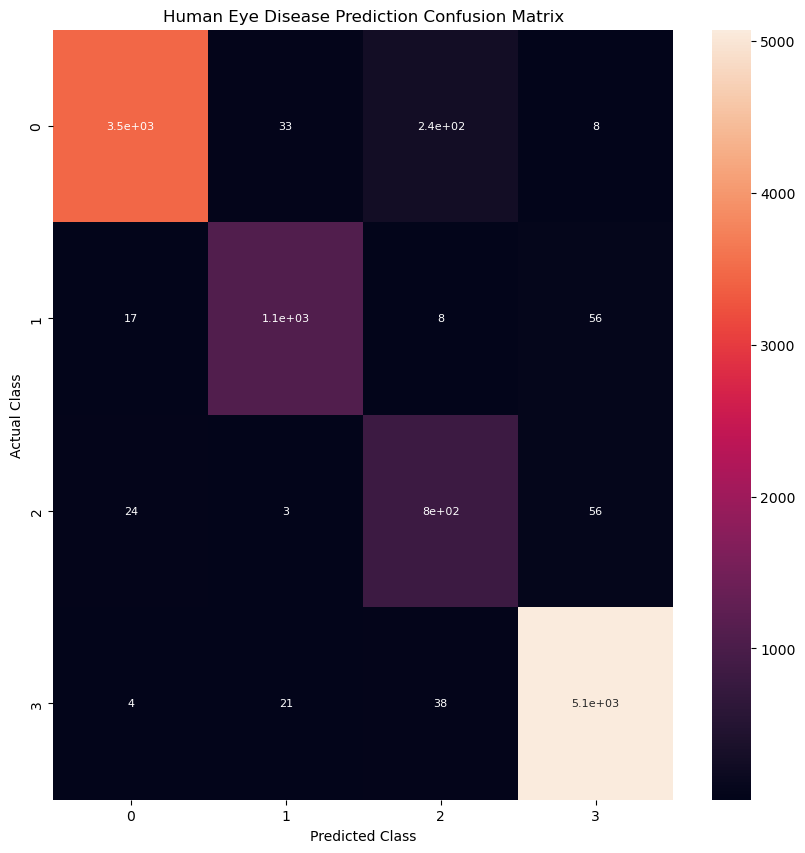

In [ ]:
import seaborn as sns
plt.figure(figsize=(10,10))
sns.heatmap(cm,annot=True,annot_kws={"size":8})
plt.xlabel("Predicted Class",fontsize=10)
plt.ylabel("Actual Class",fontsize=10)
plt.title("Human Eye Disease Prediction Confusion Matrix",fontsize=12)
plt.show()